In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [30]:
correct = pd.read_csv("Pb_labeled.csv")

GRQ2_track = correct['GRQ2charge']
TOT=correct['LASTOT']
Lx=correct['LASX']
GRtiming=correct['GRQ2timing']
LAStiming=correct['LASQ1timing']
TDiff=LAStiming-GRtiming

#PID
PID_gated = correct[
    (GRQ2_track > 213.276 - 21.194 * 5) & (GRQ2_track < 213.276 + 21.194 * 5) & (TOT+0.0430496*Lx-1.3842e-5*(Lx**2)>170) & (TOT+0.0430496*Lx-1.3842e-5*(Lx**2)<260)
]

TOT_alpha=PID_gated['LASTOT']
Lx_alpha=PID_gated['LASX']
GRtiming_alpha=PID_gated['GRQ2timing']
LAStiming_alpha=PID_gated['LASQ1timing']
TDiff_alpha=LAStiming_alpha-GRtiming_alpha

#Tp, Ta制限
# --- 物理量の計算 ---
GRX = PID_gated['GRX']
LASX = PID_gated['LASX']
LASA = PID_gated['LASA']

# Tp, Tαの計算
Tp = (((GRX * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
LASX_f = LASA * (-2.57 * Tp + 1274.57) + LASX
T_alpha_f = 0.02746 * LASX_f + 63.804

PID_gated = PID_gated[
    (Tp > 305) & (Tp < 330) & (T_alpha_f > 55) & (T_alpha_f < 80)
]

In [22]:
# #variables
# variable=PID_gated['GRQ2charge']
# #hist range
# range_min=-500
# range_max=500
# #bin width
# x_bin_width=1
# ####################################################

# fig=plt.figure()
# ax=fig.add_subplot(111)

# bin_width = x_bin_width # ビン幅を10に設定
# bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
# bin_counts, bin_edges = np.histogram(variable, bins=bins)
# bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

# ax.hist(variable, bins=bins,histtype='step', color='blue', linewidth=0.5)
# ax.grid()
# ax.set_xlabel('variable')
# ax.set_ylabel('counts')

In [23]:
# true coincidenceのヒストグラム
#コインシデンスゲート
true = PID_gated[
    (TDiff_alpha >= 50) & (TDiff_alpha < 110)
]

# ヒストグラムの設定
hist_min = -100
hist_max = 100
bin_width = 1
bins = np.arange(hist_min, hist_max + bin_width, bin_width)
bin_centers = (bins[:-1] + bins[1:]) / 2

# --- 物理量の計算 ---
GRX_acc = true['GRX']
LASX_acc = true['LASX']
LASA_acc = true['LASA']

# Tp, Tαの計算
Tp_acc = (((GRX_acc * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
LASX_acc_f = LASA_acc * (-2.57 * Tp_acc + 1274.57) + LASX_acc
T_alpha_acc_f = 0.02746 * LASX_acc_f + 63.804
    
# Variable (S_alpha)
variable = 392 - Tp_acc - T_alpha_acc_f

# --- ヒストグラム作成 (カウントのみ取得) ---
counts2, _ = np.histogram(variable, bins=bins)
    
# リストに追加
hist_list2 = []
hist_list2.append(counts2)

/var/folders/6q/n4qlty390djctk6jtn7xq4940000gn/T/ipykernel_1057/2314831593.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  true = PID_gated[


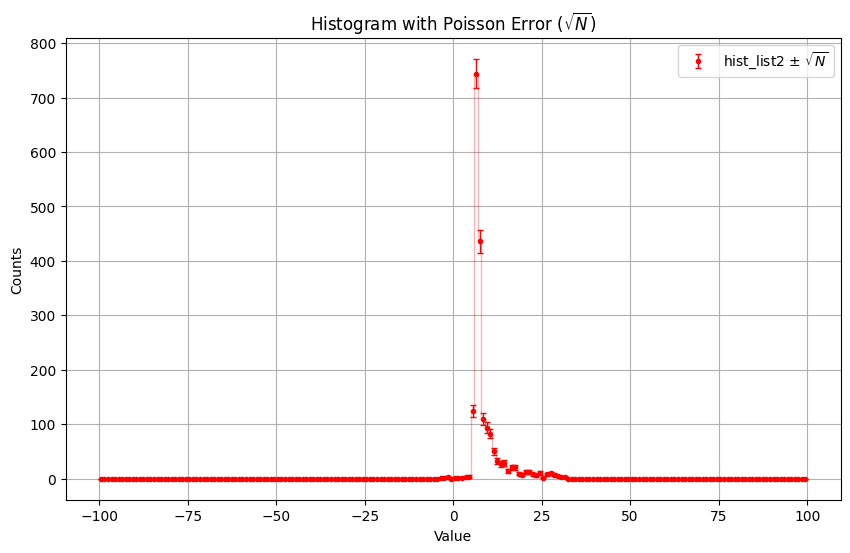

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# --- 事前準備 (hist_list2 と bins は作成済みと仮定) ---
# hist_list2: ヒストグラムのカウント数配列 (1次元)
# bins: ビンの境界配列

# ビンの中心を計算
bin_centers = (bins[:-1] + bins[1:]) / 2

# もし hist_list2 がリストの中に入っている場合 ([array(...)]) は取り出す
# hist_list2 = hist_list2[0] 

# --- 1. 誤差の計算 (ルートN) ---
# カウント数の平方根を計算
error2 = np.sqrt(hist_list2[0])

# --- 2. プロット ---
fig, ax = plt.subplots(figsize=(10, 6))

# エラーバー付きでプロット
# fmt='o' で点として描画し、エラーバーを付けます
ax.errorbar(bin_centers, hist_list2[0], yerr=error2, 
            fmt='o', markersize=3, capsize=2, linewidth=1, color='red',
            label='hist_list2 ± $\sqrt{N}$')

# 形状を見やすくするために、薄くステップ状の線も重ねて描くのが一般的です
ax.step(bin_centers, hist_list2[0], where='mid', color='red', alpha=0.3, linewidth=1)

ax.set_xlabel('Value')
ax.set_ylabel('Counts')
ax.set_title('Histogram with Poisson Error ($\sqrt{N}$)')
ax.legend()
ax.grid(True)

plt.show()

/var/folders/6q/n4qlty390djctk6jtn7xq4940000gn/T/ipykernel_1057/3847617215.py:30: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = PID_gated[
/var/folders/6q/n4qlty390djctk6jtn7xq4940000gn/T/ipykernel_1057/3847617215.py:30: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = PID_gated[
/var/folders/6q/n4qlty390djctk6jtn7xq4940000gn/T/ipykernel_1057/3847617215.py:30: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = PID_gated[
/var/folders/6q/n4qlty390djctk6jtn7xq4940000gn/T/ipykernel_1057/3847617215.py:30: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = PID_gated[
/var/folders/6q/n4qlty390djctk6jtn7xq4940000gn/T/ipykernel_1057/3847617215.py:30: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = PID_gated[
/var/folders/6q/n4qlty390djctk6jtn7xq4940000gn/T/ipykernel_1057/3847617215.py:69: UserWarning: Boole

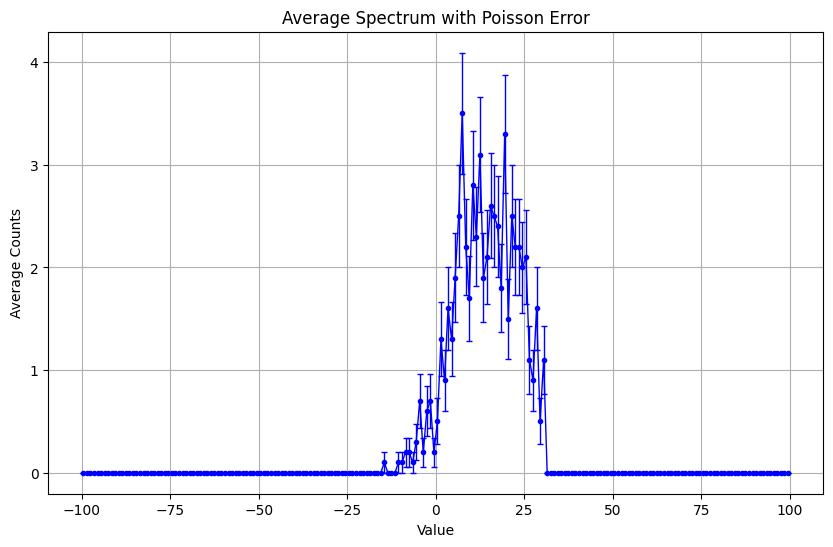

In [25]:
# アクシデンタルの誤差を再考
# 誤差棒の大きさはfrac{\sqrtN}{10}です

import numpy as np
import matplotlib.pyplot as plt

# -250から50まで


# --- 1. 設定パラメータ ---
window_width = 60       # TDiffのウィンドウ幅
start_tdiff = -250      # 開始位置
end_tdiff = 50         # 終了位置

# ヒストグラムの設定（全てのウィンドウで共通にする必要があります）
hist_min = -100
hist_max = 100
bin_width = 1
bins = np.arange(hist_min, hist_max + bin_width, bin_width)
bin_centers = (bins[:-1] + bins[1:]) / 2

# ヒストグラムデータを格納するリスト
hist_list = []

# --- 2. ループ処理で各範囲のヒストグラムを取得 ---
for t_start in range(start_tdiff, end_tdiff, window_width):
    t_end = t_start + window_width
    
    # データの抽出
    subset = PID_gated[
        (TDiff_alpha >= t_start) & (TDiff_alpha < t_end)
    ]
    
    # データが少なすぎる場合はノイズになるのでスキップ（必要に応じて調整）
    if len(subset) < 10:
        continue

    # --- 物理量の計算 ---
    GRX_acc = subset['GRX']
    LASX_acc = subset['LASX']
    LASA_acc = subset['LASA']

    # Tp, Tαの計算
    Tp_acc = (((GRX_acc * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
    LASX_acc_f = LASA_acc * (-2.57 * Tp_acc + 1274.57) + LASX_acc
    T_alpha_acc_f = 0.02746 * LASX_acc_f + 63.804
    
    # Variable (S_alpha)
    variable = 392 - Tp_acc - T_alpha_acc_f

    # --- ヒストグラム作成 (カウントのみ取得) ---
    counts, _ = np.histogram(variable, bins=bins)
    
    # リストに追加
    hist_list.append(counts)



#110から410
window_width = 60       # TDiffのウィンドウ幅
start_tdiff = 110      # 開始位置
end_tdiff = 410         # 終了位置

# --- 2. ループ処理で各範囲のヒストグラムを取得 ---
for t_start in range(start_tdiff, end_tdiff, window_width):
    t_end = t_start + window_width
    
    # データの抽出
    subset = PID_gated[
        (TDiff_alpha >= t_start) & (TDiff_alpha < t_end)
    ]
    
    # データが少なすぎる場合はノイズになるのでスキップ（必要に応じて調整）
    if len(subset) < 10:
        continue

    # --- 物理量の計算 ---
    GRX_acc = subset['GRX']
    LASX_acc = subset['LASX']
    LASA_acc = subset['LASA']

    # Tp, Tαの計算
    Tp_acc = (((GRX_acc * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
    LASX_acc_f = LASA_acc * (-2.57 * Tp_acc + 1274.57) + LASX_acc
    T_alpha_acc_f = 0.02746 * LASX_acc_f + 63.804
    
    # Variable (S_alpha)
    variable = 392 - Tp_acc - T_alpha_acc_f

    # --- ヒストグラム作成 (カウントのみ取得) ---
    counts, _ = np.histogram(variable, bins=bins)
    
    # リストに追加
    hist_list.append(counts)



# --- 3. 平均と誤差の計算 ---

# リストをNumPy配列（行列）に変換
# 行: 各TDiffウィンドウ, 列: 各ビン
hist_matrix = np.array(hist_list)

# # 平均スペクトル
mean_spectrum = np.mean(hist_matrix, axis=0)
summed_spectrum = np.sum(hist_matrix, axis=0)
error = np.sqrt(summed_spectrum) / 10

# --- 4. プロット ---
fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(bin_centers, mean_spectrum, yerr=error, 
                fmt='-o', markersize=3, capsize=2, linewidth=1, color='blue',
                label='Averaged Spectrum ± StdDev')
    
#     # 参考までに個別のスペクトルを薄く表示（ばらつき具合を目視するため）
# for i in range(10):
#     ax.step(bin_centers, hist_matrix[i], where='mid', color='gray', alpha=0.5, linewidth=0.5)

#     ax.set_xlabel('$S_\\alpha$ Value')
#     ax.set_ylabel('Average Counts')
#     ax.set_title(f'Averaged Spectrum over 10 Time Windows')
#     ax.set_ylim(0, 200)
#     ax.grid(True)
#     ax.legend()
    
#     plt.show()

# else:
#     print("No valid data found in the specified ranges.")



ax.set_xlabel('Value')
ax.set_ylabel('Average Counts')
ax.set_title('Average Spectrum with Poisson Error')
ax.grid(True)
# ax.legend()

plt.show()

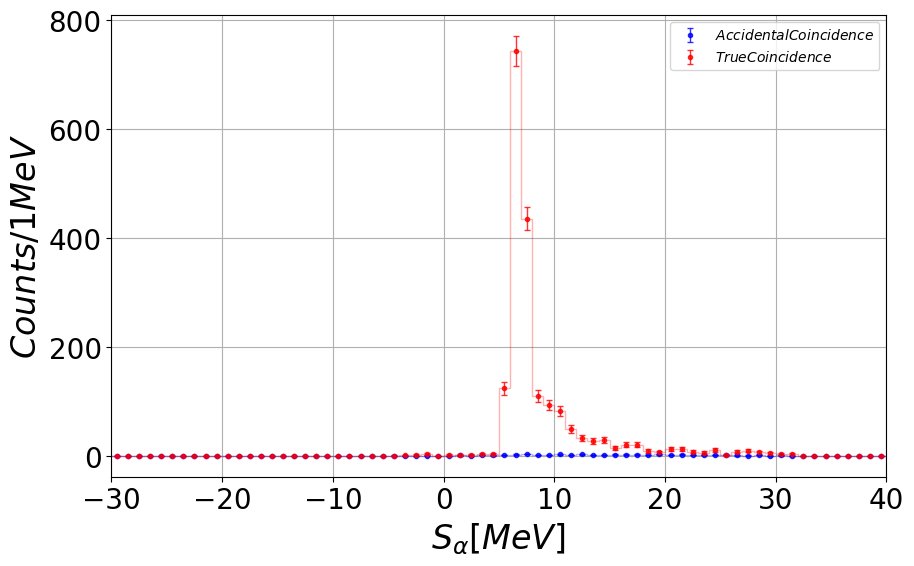

In [26]:
#便宜的に
N_samples = 10

# --- 3. プロット ---
fig, ax = plt.subplots(figsize=(10, 6))

# (A) hist_list1 (BG Mean) の描画
ax.errorbar(bin_centers, mean_spectrum, yerr=error, 
            fmt='o', markersize=3, capsize=2, linewidth=1, color='blue', alpha=0.8,
            label=r'$Accidental Coincidence$')

ax.tick_params(axis='both', labelsize=20)
# 視認用ライン
ax.step(bin_centers, mean_spectrum, where='mid', color='blue', alpha=0.3, linewidth=1)


# (B) hist_list2 (Target) の描画
ax.errorbar(bin_centers, hist_list2[0], yerr=error2, 
            fmt='o', markersize=3, capsize=2, linewidth=1, color='red', alpha=0.8,
            label=r'$True Coincidence$')
# 視認用ライン
ax.step(bin_centers, hist_list2[0], where='mid', color='red', alpha=0.3, linewidth=1)


# グラフの設定
ax.set_xlabel(r'$S_\alpha[MeV]$', fontsize=24)
ax.set_ylabel(r'$Counts/1MeV$', fontsize=24)
# ax.set_title('aaa')
ax.set_xlim(-30, 40)
ax.legend()
ax.grid(True)

plt.show()

In [27]:
#コインシデンスゲート
true = PID_gated[
    (TDiff_alpha >= 50) & (TDiff_alpha < 110)
]

# ヒストグラムの設定（全てのウィンドウで共通にする必要があります）
hist_min = -100
hist_max = 100
bin_width = 1
bins = np.arange(hist_min, hist_max + bin_width, bin_width)
bin_centers = (bins[:-1] + bins[1:]) / 2

# --- 物理量の計算 ---
GRX_acc = true['GRX']
LASX_acc = true['LASX']
LASA_acc = true['LASA']

# Tp, Tαの計算
Tp_acc = (((GRX_acc * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
LASX_acc_f = LASA_acc * (-2.57 * Tp_acc + 1274.57) + LASX_acc
T_alpha_acc_f = 0.02746 * LASX_acc_f + 63.804
    
# Variable (S_alpha)
variable = 392 - Tp_acc - T_alpha_acc_f

# --- ヒストグラム作成 (カウントのみ取得) ---
counts2, _ = np.histogram(variable, bins=bins)
    
# リストに追加
hist_list2 = []
hist_list2.append(counts2)

/var/folders/6q/n4qlty390djctk6jtn7xq4940000gn/T/ipykernel_1057/279952240.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  true = PID_gated[


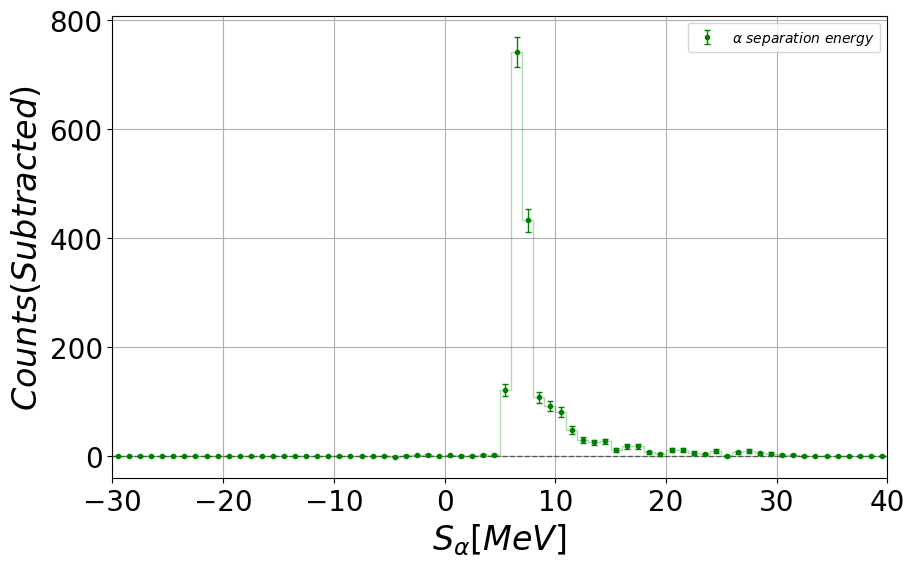

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# --- データの準備 (既存の変数を使用する前提) ---
# hist_list1: [array([counts...]), ...] (バックグラウンド用の複数のスペクトル)
# hist_list2: array([counts...]) (ターゲットの単一スペクトル)
# bin_centers: ビンの中心座標

# NumPy配列化
hist_matrix1 = np.array(hist_list)
y_data2 = np.array(hist_list2).flatten() # 1次元化

# --- 1. hist_list1 (平均) の計算 ---
N_samples = hist_matrix1.shape[0] # 積み上げたサンプル数
mean1 = np.mean(hist_matrix1, axis=0) # 平均値
std1 = np.std(hist_matrix1, axis=0, ddof=1) # 標準偏差
err1 = std1 / np.sqrt(N_samples) # 平均値の標準誤差 (SEM)

# --- 2. hist_list2 の誤差計算 ---
# カウント数のルート (ポアソン誤差)
# 負の値や0が入る可能性も考慮して絶対値をとるか、最小値を設定することがあるが、
# 通常は単純に sqrt(counts) で計算
error2 = np.sqrt(y_data2)

# --- 3. 引き算と誤差伝播 ---
diff_spectrum = y_data2 - mean1

# 誤差の合成 (二乗和のルート)
diff_error = np.sqrt(error2**2 + error**2)


# --- 4. プロット ---
fig, ax = plt.subplots(figsize=(10, 6))

# 0のライン（基準線）を引く
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# 引き算した結果をプロット
ax.errorbar(bin_centers, diff_spectrum, yerr=diff_error,
            fmt='o', markersize=3, capsize=2, linewidth=1, color='green',
            label=r'${\alpha}{\ }separation{\ }energy$')
ax.tick_params(axis='both', labelsize=20)
# ステップ状の線も薄く重ねて形状を見やすくする
ax.step(bin_centers, diff_spectrum, where='mid', color='green', alpha=0.3, linewidth=1)

ax.set_xlabel(r'$S_{\alpha}[MeV]$', fontsize=24)
ax.set_ylabel(r'$Counts (Subtracted)$', fontsize=24)
# ax.set_title('Difference Spectrum with Error Propagation')
ax.set_xlim(-30,40)
ax.legend()
ax.grid(True)

plt.show()

In [29]:
P

NameError: name 'P' is not defined